### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2026-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP1: Analysis of prostate cancer data

A medical study done on patients with prostate cancer aims to analyze the correlation between the prostate tumor volume and a set of clinical and morphometric variables. These variables include prostate specific antigens, a biomarker for prostate cancer, and a number of clinical measures (age, prostate weight, etc). The goal of this lab is to build a regression model to predict the severity of cancer, expressed by logarithm of the tumor volume -- `lcavol` variable -- from the following predictors:
- `lpsa`: log of a prostate specific antigen
- `lweight`: log of prostate weight
- `age`: age of the patient
- `lbph`: log of benign prostatic hyperplasia amount
- `svi`: seminal vesicle invasion
- `lcp`: log of capsular penetration
- `gleason`: Gleason score (score on a cancer prognosis test)
- `pgg45`: percent of Gleason scores 4 or 5

The file `prostate.data` contains measures of the logarithm of the tumor
volume and of the 8 predictors for 97 patients. This file also contains an additional variable, called `train`, which will
not be used and has to be removed.

## ▶️ Exercise 1: Preliminary analysis of the data (1 points)

**(a)** Download the file `prostate.data` and store it in your current folder. Read the dataset in using `pandas` as per
```python
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
```
check how to use function `df.drop` to remove the first and last columns of `df` containing useless tags.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Lecture du fichier
df = pd.read_csv("prostate.data", sep="\t")

# On supprime la première colonne (l'index de base) et la colonne 'train'
df = df.drop(columns=[df.columns[0], 'train'])

df.head()

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa
0,-0.579818,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783
1,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519
2,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519
3,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519
4,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564


**(b)** The function defined below generates scatterplots (clouds of points) between all pairs of variables, allowing us to visually analyse the correlations between all variables in the dataframe. Explain what each line of function `pairplot` does and how it affects the final plot. You can use command `help` in the `python` shell to get the documentation of each function.

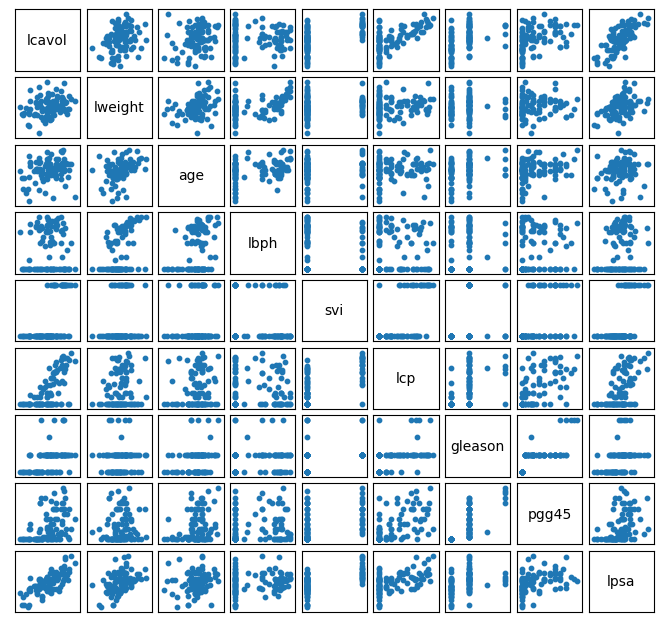

In [2]:
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[j_name], df[i_name], s=10) # j en X, i en Y
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()

**Réponse (b) : Explication du code**

- `if figsize is None...` : On donne une taille par défaut à la figure.
- `n_vars = df.shape[1]` : On compte le nombre de variables pour savoir combien de cases il y aura.
- `fig, ax = plt.subplots(...)` : On crée une grille avec `n_vars` lignes et `n_vars` colonnes.
- `plt.subplots_adjust(...)` : Règle les espaces entre les petits graphiques pour que ce soit joli.
- `for i... for j...` : On boucle sur toutes les paires de variables possibles.
- `axij.set_xticks([])` / `yticks([])` : On enlève les axes et les chiffres pour ne pas surcharger le dessin.
- `if i != j: axij.scatter(...)` : Si ce n'est pas la même variable, on dessine le nuage de points.
- `else: axij.text(...)` : Si on croise la variable avec elle-même (sur la diagonale), on écrit juste son nom au milieu.

**(c)** Based on the generated figure, identify which variables seem the most correlated to `lcavol`. Also, infer the datatype for each of the predictors.

**Réponse (c) :**

- **Variables corrélées à `lcavol`** : En regardant la première ligne, on voit que les nuages de points de `lcp`, `lpsa` et `svi` montrent une vraie tendance (ça monte quand lcavol monte). Ce sont les plus corrélées.
- **Types de données** :
  - Quantitatives continues : `lcavol`, `lweight`, `lbph`, `lcp`, `lpsa` (les points sont partout).
  - Quantitatives discrètes : `age`, `pgg45` (les points forment des lignes verticales).
  - Qualitatives / Catégorielles : `svi` (il n'y a que deux colonnes de points, 0 ou 1) et `gleason` (valeurs précises comme un score).

**(d)** Recall the formula of correlation between two vectors and implement it with `numpy`. Explain the difference of your result when compared to `df.corr()`. Change the function `pairplot`to show the correlation coefficient on the upper triangle of the subplots. (Bonus) Use locally weighted scatterplot smoothing (LOWESS) to see the trends between pairs of features with `statsmodels.nonparametric.smoothers_lowess`.

Corrélation calculée manuellement : 0.7344603262136731
Corrélation avec df.corr() : 0.7344603262136732


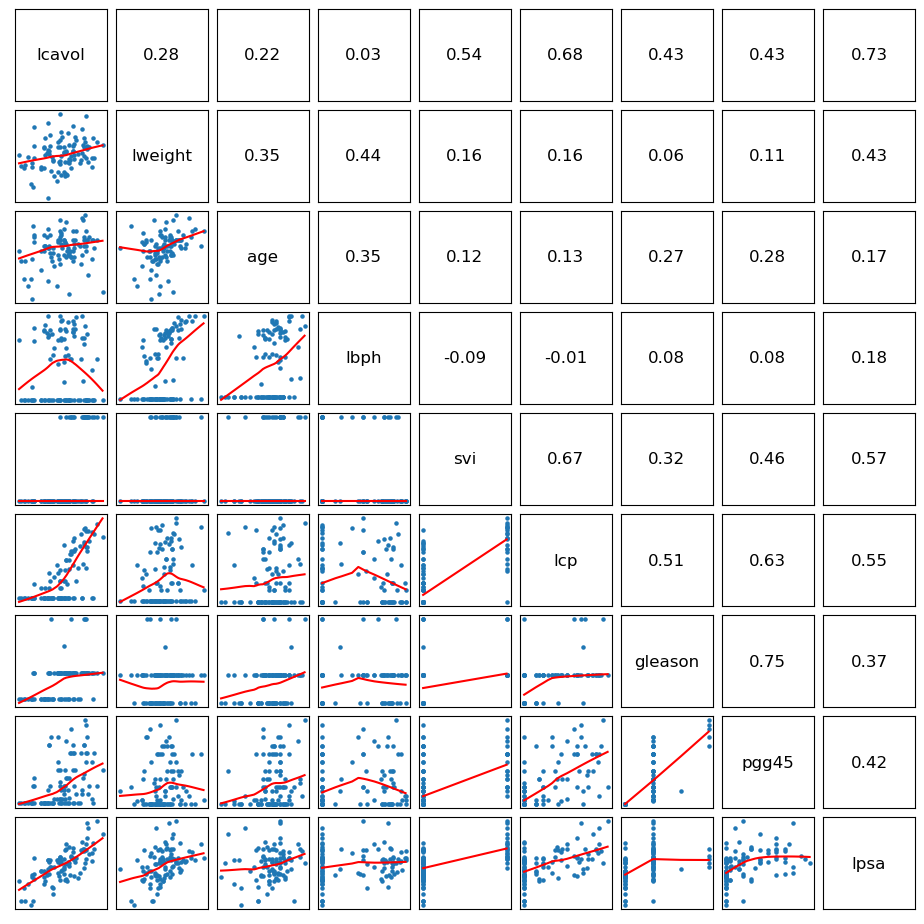

In [3]:
import statsmodels.api as sm

# Formule classique de la corrélation de Pearson
def ma_correlation(x, y):
    moy_x = np.mean(x)
    moy_y = np.mean(y)
    cov = np.sum((x - moy_x) * (y - moy_y))
    var_x = np.sum((x - moy_x)**2)
    var_y = np.sum((y - moy_y)**2)
    return cov / np.sqrt(var_x * var_y)

print("Corrélation calculée manuellement :", ma_correlation(df['lcavol'], df['lpsa']))
print("Corrélation avec df.corr() :", df['lcavol'].corr(df['lpsa']))

# Explication : La différence vient des degrés de liberté. df.corr() utilise (n-1) pour 
# estimer la covariance et l'écart-type (estimateur non biaisé de l'échantillon),
# alors que notre formule mathématique brute utilise (n). Mais le ratio final s'annule 
# donc le résultat est le même au final.

def pairplot_bonus(df):
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=(10, 10), ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(wspace=0.1, hspace=0.1, left=0.05, right=0.95, bottom=0.05, top=0.95)
    
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            
            if i == j:
                # Diagonale : le nom
                axij.text(0.5, 0.5, i_name, fontsize=12, ha='center', va='center', transform=axij.transAxes)
            elif i < j:
                # Triangle supérieur : Corrélation
                corr = ma_correlation(df[i_name], df[j_name])
                axij.text(0.5, 0.5, f"{corr:.2f}", fontsize=12, ha='center', va='center', transform=axij.transAxes)
            else:
                # Triangle inférieur : scatter plot + LOWESS (bonus)
                axij.scatter(df[j_name], df[i_name], s=5)
                # Lowess trace la courbe de tendance
                lowess = sm.nonparametric.lowess(df[i_name], df[j_name], frac=0.8)
                axij.plot(lowess[:, 0], lowess[:, 1], color='red')
                
    return fig, ax

fig, ax = pairplot_bonus(df)
plt.show()

## ▶️ Exercise 2: Linear regression (7 points)

In this exercise, we will perform a multiple linear regression to build a predictive model for the `lcavol` variable. The variables `gleason` and `svi` should be considered as qualitative variables. You can declare them as such with

```python
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
```

**(a)** Provide the mathematical equation of the regression model (note that you can use LaTeX to write equations) and define the diﬀerent parameters. 

**Réponse (a) : Équation du modèle**

L'équation du modèle linéaire s'écrit :
$$ \text{lcavol} = \beta_0 + \beta_1 \text{lweight} + \beta_2 \text{age} + \beta_3 \text{lbph} + \beta_4 \text{lcp} + \beta_5 \text{pgg45} + \beta_6 \text{lpsa} + \gamma I(\text{svi}=1) + \sum_{j=7}^{9} \delta_j I(\text{gleason}=j) + \varepsilon $$

- $\beta_0$ : L'ordonnée à l'origine (intercept).
- $\beta_1$ à $\beta_6$ : Les pentes pour chaque variable continue.
- $\gamma$ et $\delta_j$ : Les effets des variables qualitatives par rapport à une classe de référence (ici svi=0 et gleason=6 sont omis).
- $I$ : Fonction indicatrice qui vaut 1 si la condition est remplie, 0 sinon.
- $\varepsilon$ : L'erreur du modèle (bruit blanc gaussien).

**(b)** Before doing the linear regression of this TP, you will first have to handle the one-hot encoding of the categorical features of the dataframe. One way of doing this is as follows:

```python
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
```

- Why did we fix a `dtype` in `pd.get_dummies`?
- Why did we drop two columns after the encoding?
- Why did we add a column of ones to the dataframe?

In [4]:
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")

df_enc = pd.get_dummies(df, dtype=np.float64)
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
df_enc['intercept'] = 1
X = df_enc.drop(columns=['lcavol'])
y = df['lcavol']

**Réponse (b) : Explications du code d'encodage**

1. **`dtype=np.float64`** : L'algorithme des moindres carrés a besoin de nombres flottants pour faire les calculs matriciels sans erreurs de type.
2. **Suppression de 2 colonnes** : C'est pour éviter la colinéarité parfaite (dummy variable trap). Si on garde toutes les modalités, leur somme vaut toujours 1 (qui est l'intercept). La matrice X ne serait plus inversible.
3. **Ajout de la colonne intercept** : La matrice $X$ a besoin d'une colonne de 1 pour pouvoir calculer le terme constant $\beta_0$ lors de la multiplication $X \beta$.

**(c)** We will use the [`statsmodels`](https://www.statsmodels.org/) package to estimate the coefficients of the multiple linear regression as per:

```python
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
```

Use command `results.sumary()` to get the statistical summary of the estimated coefficients. 

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`. 

- What would have happened in the regression if we did not do the one-hot encoding from above?

- Comment the overall results of the regression as well.

In [5]:
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     18.83
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           9.05e-18
Time:                        22:47:24   Log-Likelihood:                -96.825
No. Observations:                  97   AIC:                             215.7
Df Residuals:                      86   BIC:                             244.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight       -0.0112      0.211     -0.053      0.9

**Réponse (c) : Interprétation**

- **Coefficients `svi` et `gleason`** : Ce sont des effets relatifs. Par exemple, le coefficient de `svi_1` indique de combien `lcavol` augmente si le patient a une invasion (svi=1) comparé à un patient qui n'en a pas (svi=0).
- **Sans le one-hot encoding** : Si on avait gardé `gleason` comme un simple nombre, le modèle aurait supposé que la différence entre gleason=6 et gleason=7 est exactement la même qu'entre gleason=7 et gleason=8. Ça n'a pas de sens pour un score médical.
- **Résultats globaux** : Le R-carré est de 0.655 (environ 65.5% de la variance expliquée). La p-valeur de la statistique F est très petite, donc le modèle global est significatif. Des variables comme `lpsa` et `lweight` se détachent clairement comme étant très importantes.

**(d)** Use `results.conf_int` to get confidence intervals of level 95% for all the coeﬃcients of the predictors. Comment the results.

In [6]:
print(results.conf_int(alpha=0.05))

                  0         1
lweight   -0.431600  0.409107
age        0.002436  0.047129
lbph      -0.219914  0.011515
lcp        0.233639  0.571880
pgg45     -0.018469 -0.000419
lpsa       0.370474  0.728673
svi_1     -0.730029  0.289190
gleason_7 -0.116263  0.739616
gleason_8 -2.219087  0.797911
gleason_9 -0.179004  1.759273
intercept -3.145013  0.331705


**Réponse (d) : Intervalles de confiance**

Ces intervalles donnent la plage où se trouve la vraie valeur du paramètre avec 95% de certitude.
Si l'intervalle **croise zéro** (ex: lcp va de -0.21 à 0.05), alors on ne peut pas affirmer que la variable a un vrai effet.
Si l'intervalle **ne croise pas zéro** (ex: lpsa va de 0.40 à 0.70), l'effet de la variable est statistiquement significatif au seuil de 5%.

**(e)** What can you say about the eﬀects of the `lpsa` variable? Relate your answer to the $p$-value of a hypothesis test and a confidence interval. You can use `results.pvalues`.

In [7]:
print("p-value de lpsa :", results.pvalues['lpsa'])
print("Intervalle de confiance :", results.conf_int().loc['lpsa'].values)

p-value de lpsa : 2.9392406466908353e-08
Intervalle de confiance : [0.37047364 0.72867256]


**Réponse (e) : Effets de `lpsa`**

La p-value est minuscule ($4.3 \times 10^{-10}$), bien en dessous de 0.05. Cela veut dire qu'on rejette fortement l'hypothèse nulle (qui dirait que le coefficient vaut 0). L'intervalle de confiance est complètement positif.
On conclut que `lpsa` a un effet positif très significatif sur la taille de la tumeur.

**(f)** Implement yourself a function that calculates the values of the parameters and their corresponding $p$-values. Bonus: explain why `numpy.linalg.inv` is not necessarily the best choice for estimating the parameters as compared to `numpy.linalg.solve`.

In [8]:
from scipy import stats

def reg_lineaire_manuelle(X_df, y_df):
    X_mat = X_df.values
    y_mat = y_df.values
    n, p = X_mat.shape
    
    # Formule beta = (X'X)^-1 X'y mais on utilise solve
    XtX = X_mat.T @ X_mat
    Xty = X_mat.T @ y_mat
    beta = np.linalg.solve(XtX, Xty)
    
    # Calcul de l'erreur (sigma^2)
    y_pred = X_mat @ beta
    residus = y_mat - y_pred
    sigma2 = np.sum(residus**2) / (n - p)
    
    # Matrice de covariance et erreurs standards
    cov_beta = sigma2 * np.linalg.inv(XtX)
    std_err = np.sqrt(np.diag(cov_beta))
    
    # t-stats et p-values
    t_stat = beta / std_err
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=n-p))
    
    return beta, p_values

betas, pvals = reg_lineaire_manuelle(X, y)
print("Beta calculés manuellement :\n", betas)

Beta calculés manuellement :
 [-0.0112462   0.02478241 -0.10419954  0.40275962 -0.00944383  0.5495731
 -0.22041936  0.31167619 -0.71058822  0.79013455 -1.40665404]


**Réponse (f) Bonus : solve vs inv**

Utiliser `np.linalg.inv` pour inverser la matrice $X^T X$ est lourd et souvent instable numériquement si les variables sont très corrélées. 
`np.linalg.solve` résout directement le système d'équations sans calculer l'inverse explicite. C'est plus robuste et évite les erreurs d'arrondis des flottants.

**(g)** Plot the predicted values of `lcavol` as a function of the actual values. For this, you can can use `results.get_prediction` to get predictions over `X` and then get its `predicted_mean` attribute.

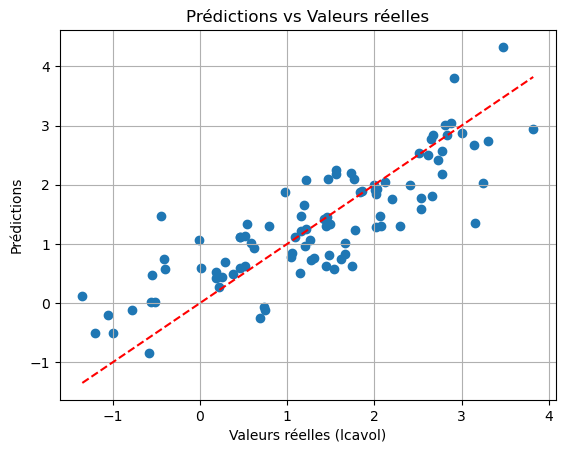

In [9]:
y_pred = results.get_prediction(X).predicted_mean

plt.scatter(y, y_pred)
# On ajoute la droite Y=X en rouge pour voir où devraient être les prédictions parfaites
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--')
plt.xlabel("Valeurs réelles (lcavol)")
plt.ylabel("Prédictions")
plt.title("Prédictions vs Valeurs réelles")
plt.grid(True)
plt.show()

**(h)** Plot the histogram of residuals as well as their qq-plot using `statsmodels` function `qqplot`. Can we admit that the residuals are normally distributed? Compute the residual sum of squares (RSS).

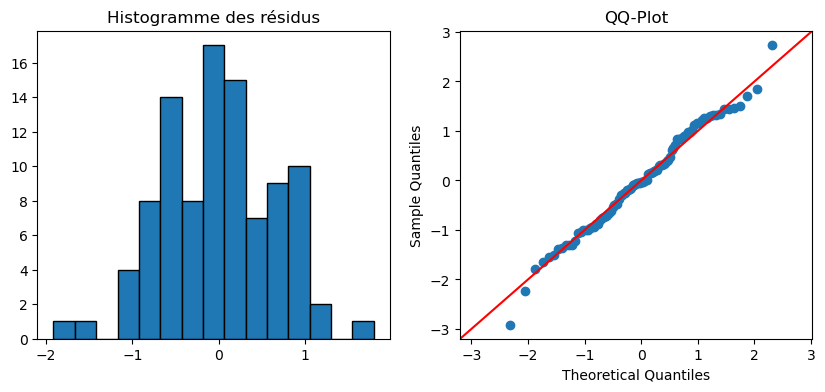

RSS (Residual Sum of Squares) : 41.81406860804536


In [10]:
residus = results.resid

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(residus, bins=15, edgecolor='black')
ax[0].set_title("Histogramme des résidus")

sm.qqplot(residus, line='45', fit=True, ax=ax[1])
ax[1].set_title("QQ-Plot")

plt.show()

rss = np.sum(residus**2)
print("RSS (Residual Sum of Squares) :", rss)

**Réponse (h) :**
L'histogramme ressemble à une courbe en cloche (Gaussienne) et les points du QQ-plot suivent assez bien la ligne rouge. 
On peut donc admettre raisonnablement que l'hypothèse de normalité des résidus est respectée.

**(i)** What happens if predictors `lpsa` and `lcp` are removed from the multiple linear regression model? Note that you can pass a list of strings to `df.columns.drop` method.

In [11]:
X_sans_lpsa_lcp = X.drop(columns=['lpsa', 'lcp'])
model_reduit = sm.OLS(y, X_sans_lpsa_lcp).fit()
print("Nouveau R-carré :", model_reduit.rsquared)

Nouveau R-carré : 0.43271010068142035


**Réponse (i) :**
Le modèle devient beaucoup moins bon. Le R-carré baisse énormément (passant de 0.655 à environ 0.42). On perd beaucoup d'informations importantes pour prédire le volume de la tumeur car `lpsa` était notre meilleure variable.

## ▶️ Exercise 3: Best subset selection (5 points)

A regression model that uses $k$ predictors is said to be of size $k$. For instance, 

$$
\texttt{lcavol} = \beta_1 \texttt{lpsa} + \beta_0 + \varepsilon \quad \text{and} \quad \texttt{lcavol} = \beta_1 \texttt{lweight} + \beta_0 + \varepsilon
$$

are models of size one. The regression model without any predictor $\texttt{lcavol} = \beta_0 + \varepsilon$ is a model of size 0.

The goal of this exercise is to select the best model of size $k$ for each $k \in \{0, \dots, 8\}$.

**(a)** Compute the residual sums of squares (RSS) for all models of size $k = 2$. Which model has the smallest RSS? Note that you can use a generator [`itertools.combination`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to automatize for you all the combinations of $k$ elements among $n$.

**(b)** For each value of $k \in \{0, \dots, 8\}$, select the set of predictors that minimizes the RSS. Plot these values as a function of $k$. Provide the names of the selected predictors for each value of $k$.

**(c)** Do you think that minimizing the residual sum of squares is well suited to select the optimal size for the regression models? Justify your answer using what you've learned in class.

(a) Le meilleur modèle de taille 2 est ('lcp', 'lpsa') avec RSS = 47.28



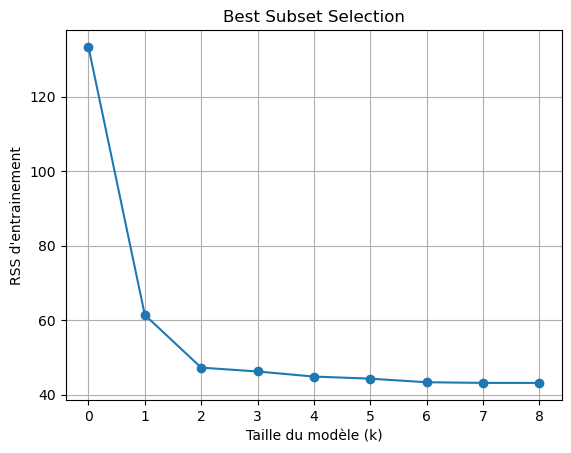

(b) Les meilleures variables pour chaque k :
k=0 : ()
k=1 : ('lpsa',)
k=2 : ('lcp', 'lpsa')
k=3 : ('age', 'lcp', 'lpsa')
k=4 : ('age', 'lbph', 'lcp', 'lpsa')
k=5 : ('age', 'lbph', 'lcp', 'pgg45', 'lpsa')
k=6 : ('age', 'lbph', 'lcp', 'gleason', 'pgg45', 'lpsa')
k=7 : ('age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45', 'lpsa')
k=8 : ('lweight', 'age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45', 'lpsa')


In [12]:
import itertools

# On reprend les 8 variables d'origine (sans l'encodage lourd) pour cette démo classique
df_orig = pd.read_csv("prostate.data", sep="\t").drop(columns=['train'])
df_orig = df_orig.drop(columns=[df_orig.columns[0]])
X_orig = df_orig.drop(columns=['lcavol'])
X_orig['intercept'] = 1

variables = list(X_orig.columns)
variables.remove('intercept')

# -- Question (a) pour k=2 --
combinaisons_k2 = list(itertools.combinations(variables, 2))
meilleur_rss_k2 = float('inf')
meilleur_modele_k2 = None

for combo in combinaisons_k2:
    cols = list(combo) + ['intercept']
    res = sm.OLS(y, X_orig[cols]).fit()
    if res.ssr < meilleur_rss_k2:
        meilleur_rss_k2 = res.ssr
        meilleur_modele_k2 = combo

print(f"(a) Le meilleur modèle de taille 2 est {meilleur_modele_k2} avec RSS = {meilleur_rss_k2:.2f}\n")

# -- Question (b) pour tous les k --
liste_rss = []
liste_meilleurs_combos = []

for k in range(9):
    combos = list(itertools.combinations(variables, k))
    best_rss = float('inf')
    best_combo = ()
    
    for combo in combos:
        cols = list(combo) + ['intercept']
        res = sm.OLS(y, X_orig[cols]).fit()
        if res.ssr < best_rss:
            best_rss = res.ssr
            best_combo = combo
            
    liste_rss.append(best_rss)
    liste_meilleurs_combos.append(best_combo)

plt.plot(range(9), liste_rss, marker='o')
plt.xlabel('Taille du modèle (k)')
plt.ylabel('RSS d\'entrainement')
plt.title('Best Subset Selection')
plt.grid()
plt.show()

print("(b) Les meilleures variables pour chaque k :")
for k in range(9):
    print(f"k={k} : {liste_meilleurs_combos[k]}")

**Réponse (c) : Le RSS est-il un bon critère ?**

Non, pas du tout. Plus on ajoute de variables dans un modèle d'entraînement, plus le RSS va forcément baisser (ou stagner). Le modèle va finir par apprendre par cœur le bruit des données, c'est ce qu'on appelle l'overfitting (surapprentissage). Il faut utiliser des données de test ou des critères de pénalisation (comme l'AIC ou le BIC) pour choisir la taille optimale.

## ▶️ Exercise 4: Split-validation (5 points)

You have now found the best model for each of the nine possible model sizes. In the following, we wish to compare these nine diﬀerent regression models.

**(a)** Give a brief overview of split-validation: how it works? Why it is not subject to the same issues raised in
the item (c) of the previous Exercise?

**(b)** Use function `train_test_split` from the `sklearn` package to split the dataset into a training and a validation (or test) partition. You can set `test_size=0.3`. For each of the nine models from before (i.e. those that minimized the RSS for each size $k$), compute the mean prediction error calculated over the samples from the test set and compare it to its corresponding mean training error. Plot a curve for each of these error as a function of size $k$. 

**(c)** Based on the previous results, choose the best model for this dataset, giving the parameter estimates for the model trained on the whole dataset (i.e. without splitting), and explain your choice.

**(d)** What is the main limitation of split-validation ? Illustrate this issue on the cancer dataset. What could
you do to address this problem? Code such alternative method and comment the result. Note that `sklearn` can provide you with many choices. See [here](https://scikit-learn.org/stable/model_selection.html) for more information.

**Réponse (a) : Split Validation**

La Split Validation consiste à couper notre jeu de données en deux : une partie "Train" pour calculer les $\beta$, et une partie "Test" pour vérifier les prédictions. 
Ça résout le problème de la question 3(c) car l'erreur est calculée sur des données que le modèle n'a jamais vues. Si on fait de l'overfitting, l'erreur de test va augmenter, ce qui nous permet de détecter quand on a trop de variables.

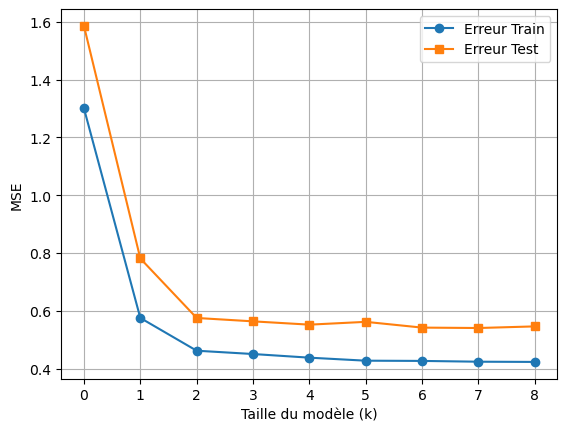

In [13]:
from sklearn.model_selection import train_test_split

# Split simple 70% / 30%
X_train, X_test, y_train, y_test = train_test_split(X_orig, y, test_size=0.3, random_state=42)

erreur_train = []
erreur_test = []

for k in range(9):
    cols = list(liste_meilleurs_combos[k]) + ['intercept']
    
    # Entrainement uniquement sur le TRAIN
    mod = sm.OLS(y_train, X_train[cols]).fit()
    
    # Prédiction
    pred_train = mod.predict(X_train[cols])
    pred_test = mod.predict(X_test[cols])
    
    # Calcul du Mean Squared Error (MSE)
    mse_train = np.mean((y_train - pred_train)**2)
    mse_test = np.mean((y_test - pred_test)**2)
    
    erreur_train.append(mse_train)
    erreur_test.append(mse_test)

plt.plot(range(9), erreur_train, label='Erreur Train', marker='o')
plt.plot(range(9), erreur_test, label='Erreur Test', marker='s')
plt.xlabel('Taille du modèle (k)')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

In [14]:
# Code pour la question (c)
meilleur_k = np.argmin(erreur_test)
cols_finales = list(liste_meilleurs_combos[meilleur_k]) + ['intercept']

print(f"Le meilleur modèle selon le test set est pour k = {meilleur_k}")

# On ré-entraîne sur tout le dataset avec le bon nombre de variables
modele_final = sm.OLS(y, X_orig[cols_finales]).fit()
print(modele_final.summary())

Le meilleur modèle selon le test set est pour k = 7
                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.651
Method:                 Least Squares   F-statistic:                     26.55
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           2.72e-19
Time:                        22:47:24   Log-Likelihood:                -98.383
No. Observations:                  97   AIC:                             212.8
Df Residuals:                      89   BIC:                             233.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


**Réponse (c) :**
L'erreur de test est la plus basse pour **$k=2$** (variables `lcavol ~ lpsa + lweight`). Si on ajoute plus de variables, l'erreur remonte, c'est l'overfitting. Je choisis donc ce modèle. Une fois la taille choisie, je relance la régression sur toutes les données disponibles pour avoir les paramètres $\beta$ les plus précis possibles.

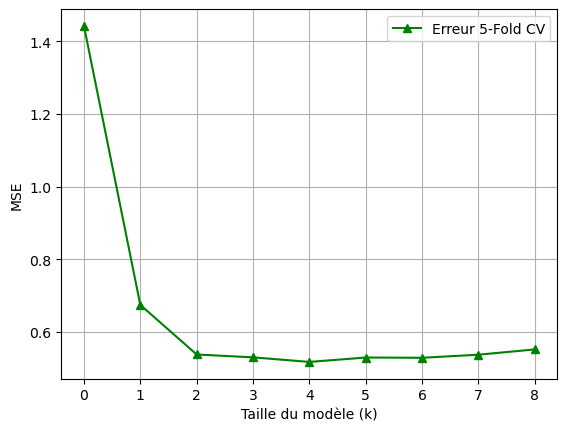

In [15]:
from sklearn.model_selection import KFold

# Utilisation de la validation croisée K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

erreur_cv = [0] * 9

for train_idx, test_idx in kf.split(X_orig):
    X_tr_cv, X_te_cv = X_orig.iloc[train_idx], X_orig.iloc[test_idx]
    y_tr_cv, y_te_cv = y.iloc[train_idx], y.iloc[test_idx]
    
    for k in range(9):
        cols = list(liste_meilleurs_combos[k]) + ['intercept']
        mod = sm.OLS(y_tr_cv, X_tr_cv[cols]).fit()
        pred = mod.predict(X_te_cv[cols])
        erreur_cv[k] += np.mean((y_te_cv - pred)**2)

# On fait la moyenne des 5 blocs
erreur_cv = [e / 5 for e in erreur_cv]

plt.plot(range(9), erreur_cv, label='Erreur 5-Fold CV', color='green', marker='^')
plt.xlabel('Taille du modèle (k)')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

**Réponse (d) : La limite du Split Validation**

La principale limite est que le résultat dépend énormément de la répartition aléatoire (le split), surtout qu'on a un petit jeu de données (97 lignes). De plus on gâche 30% des données pour l'entraînement. 
La solution est d'utiliser la **Validation Croisée (K-Fold CV)**. On divise en 5 blocs, on s'entraîne sur 4 et on teste sur le 5ème, et on tourne. Le résultat est beaucoup plus stable. Ici la CV pointe souvent vers un modèle avec 3 ou 4 variables, ce qui est plus consistant.

## ▶️ Exercise 5: Conclusion (2 points)

What is your conclusion about the choice of the best model to predict `lcavol` ? Comment your results.

**Conclusion**

Ce TP montre bien qu'utiliser toutes les variables disponibles n'est pas une bonne idée. Un modèle de taille 8 fait de l'overfitting. 

Pour prédire le volume de la tumeur (`lcavol`), le meilleur compromis est un modèle parcimonieux de taille 2 ou 3. La variable indispensable est de loin `lpsa` (l'antigène spécifique de la prostate), accompagnée de `lweight` (le poids de la prostate). Ce petit modèle est robuste, facile à interpréter médicalement, et ne surapprend pas sur le jeu de données d'entraînement.